## Introduction

The objective of this notebook is to **compare several simple long-only investment strategies:**
1. Equity buy-and-hold
2. Equity–bond buy-and-hold
3. Volatility-driven equity-to-bond switching
4. Drawdown-driven equity-to-bond switching

## Import librairies

In [504]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

## Custom function

In [505]:
def compute_metrics(price_ts, title):
    
    win_loss_ratio = price_ts.diff().clip(lower=0).sum() / -price_ts.diff().clip(upper=0).sum()
    print(f'win/loss ratio: {win_loss_ratio:.2f}')

    sharpe = (price_ts.pct_change().mean() * 252) / (price_ts.pct_change().std() * np.sqrt(252))
    print(f'sharpe ratio: {sharpe:.2f}')

    total_performance = price_ts.iloc[-1] / price_ts.iloc[0]
    n = ((price_ts.index[-1]-price_ts.index[0]).days / 365)
    x = total_performance**(1/n) -1
    print(f'annualized return: {x:.2%}')

    annual_returns = price_ts.groupby(price_ts.index.year).last().pct_change()

    multiplier = -0.3 / annual_returns.min()
    print(f'multiplier: {multiplier:.2f}')
    annual_returns_scaled = annual_returns * multiplier
    x_scaled = annual_returns_scaled.add(1).prod()**(1/len(annual_returns_scaled)) - 1
    print(f'annualized return scaled: {x_scaled:.2%}')

    plt.figure(figsize=(13, 4))
    sns.lineplot(data=price_ts)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns.index.astype(str), y=annual_returns.values)
    plt.title(f'Annual Returns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    sns.barplot(x=annual_returns_scaled.index.astype(str), y=annual_returns_scaled.values)
    plt.title(f'Annual Returns Scaled')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

## Inputs

In [506]:
eq_asset = 'SPY'
bond_asset = 'IBGS.MI'
vol_threshold_buy = 0.9
vol_threshold_sell = 0.04
vol_window = 5
dd_threshold_buy = 0.70
dd_threshold_sell = 1.0


## Script

In [507]:
df_eq = pd.read_csv(f'data/{eq_asset}.csv', index_col=0, parse_dates=True)
df_bond = pd.read_csv(f'data/{bond_asset}.csv', index_col=0, parse_dates=True)

## 1. Equity buy-and-hold

win/loss ratio: 1.13
sharpe ratio: 0.52
annualized return: 8.45%
multiplier: 0.82
annualized return scaled: 6.50%


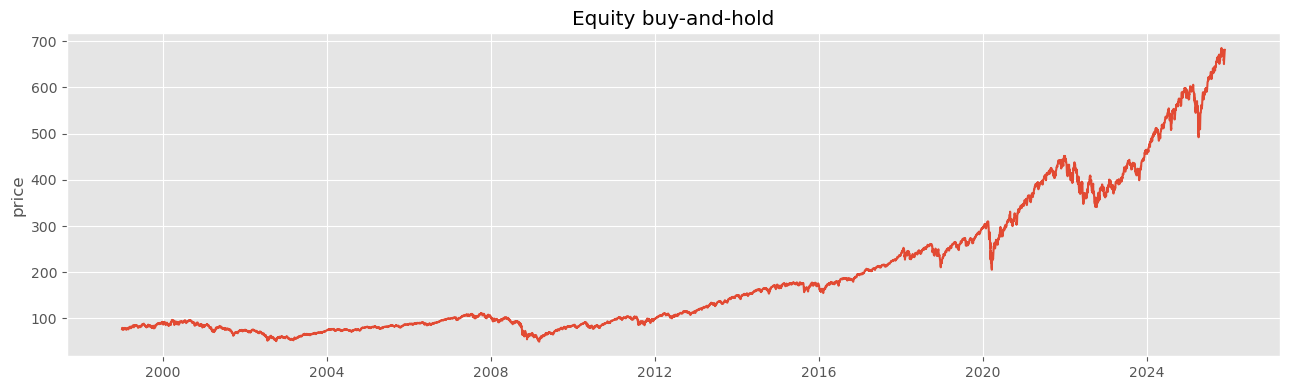

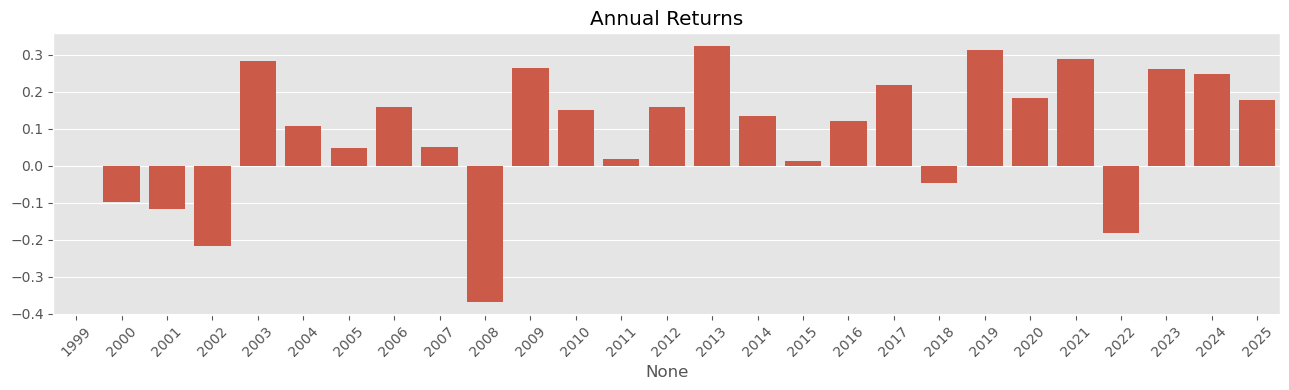

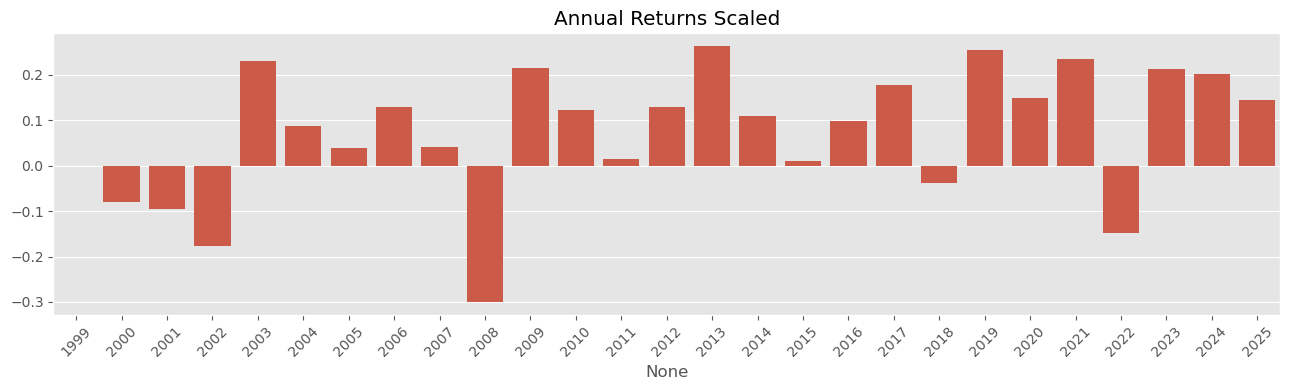

In [508]:
compute_metrics(df_eq.price, 'Equity buy-and-hold')

## 2. Equity–bond buy-and-hold

Optimal Weights:
Equity: 15.72%
Bond: 84.28%
win/loss ratio: 1.16
sharpe ratio: 0.72
annualized return: 2.59%
multiplier: 4.77
annualized return scaled: 12.56%


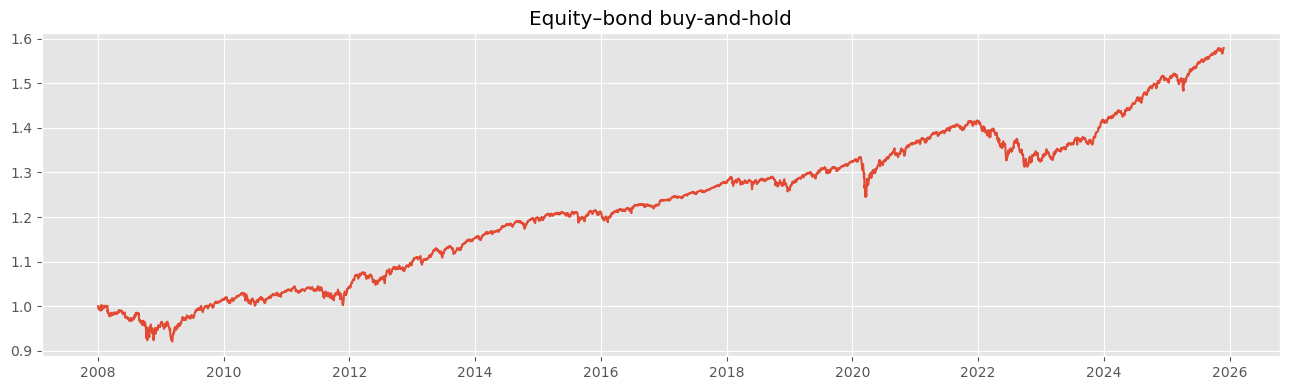

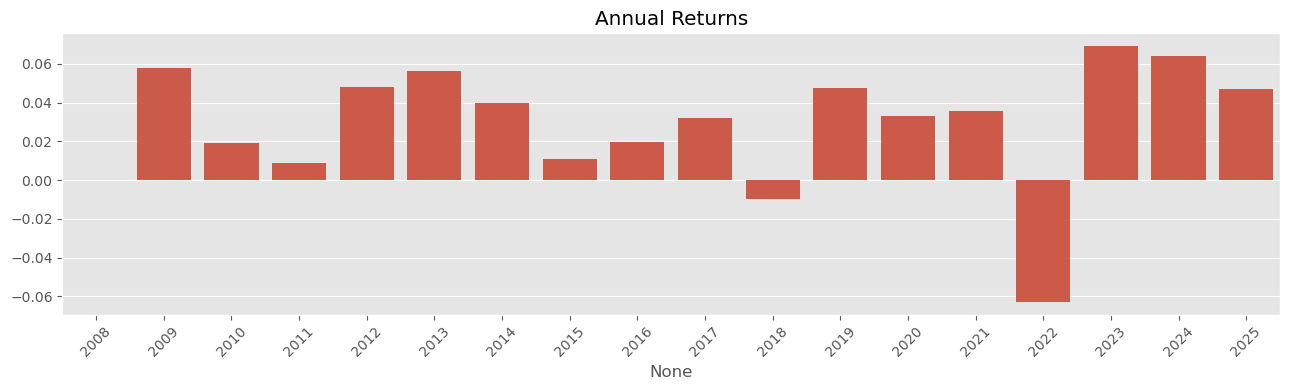

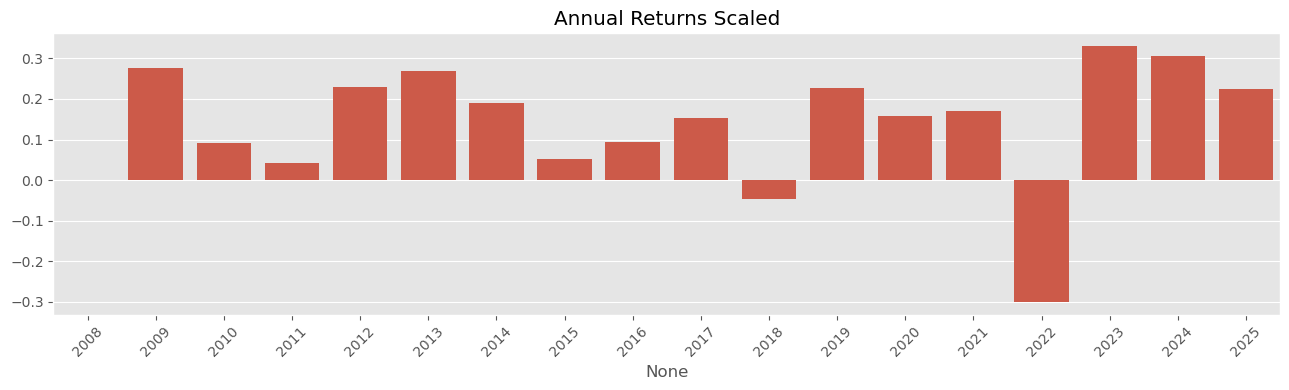

In [509]:
df_price = pd.concat([df_eq.price, df_bond.price], axis=1, keys=['equity', 'bond']).dropna()
returns = df_price.pct_change().dropna()
mu = returns.mean() * 252
sigma = returns.cov() * 252
inv_sigma = np.linalg.inv(sigma)
z = np.dot(inv_sigma, mu)
w_opt = z / np.sum(z)
print(f'Optimal Weights:\nEquity: {w_opt[0]:.2%}\nBond: {w_opt[1]:.2%}')
portfolio_returns = returns.dot(w_opt)
portfolio_level = portfolio_returns.add(1).cumprod()

compute_metrics(portfolio_level, 'Equity–bond buy-and-hold')

## 3. Volatility-driven equity-to-bond switching

win/loss ratio: 1.21
sharpe ratio: 0.39
annualized return: 4.15%
multiplier: 7.03
annualized return scaled: 20.63%


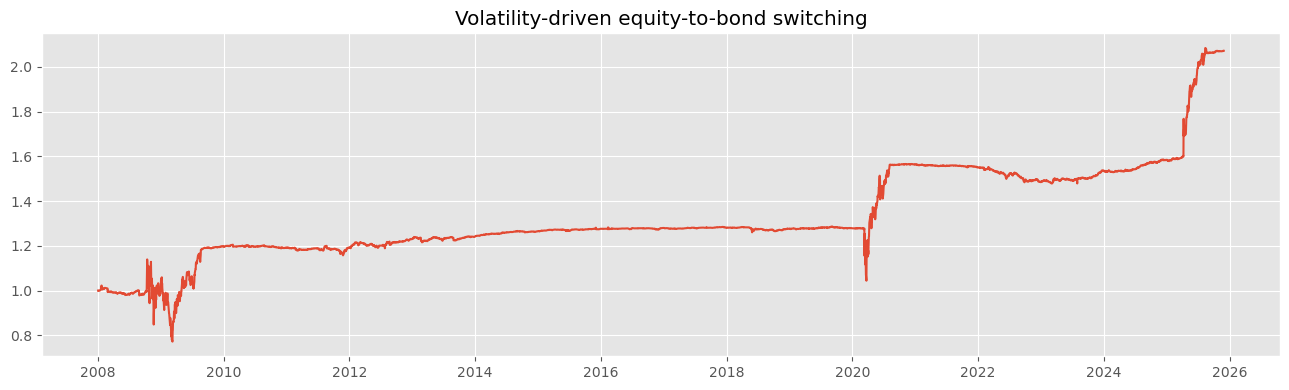

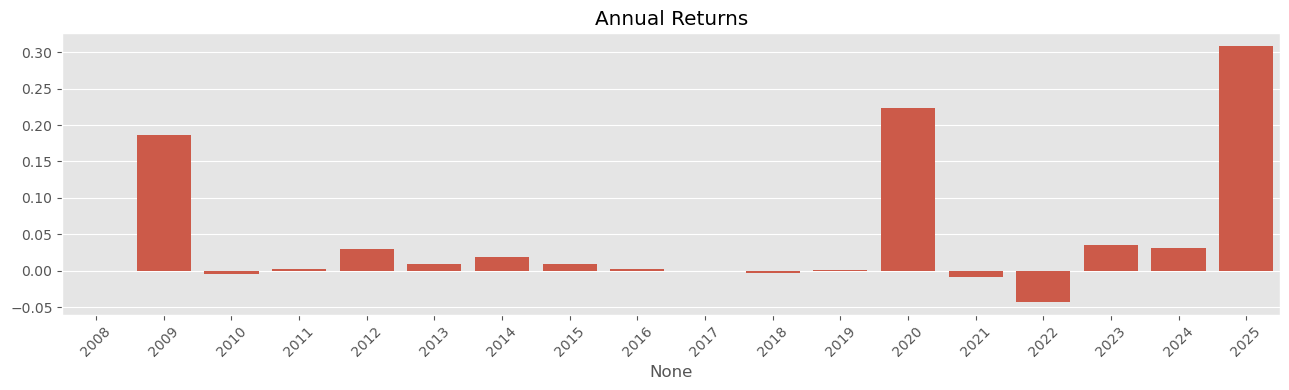

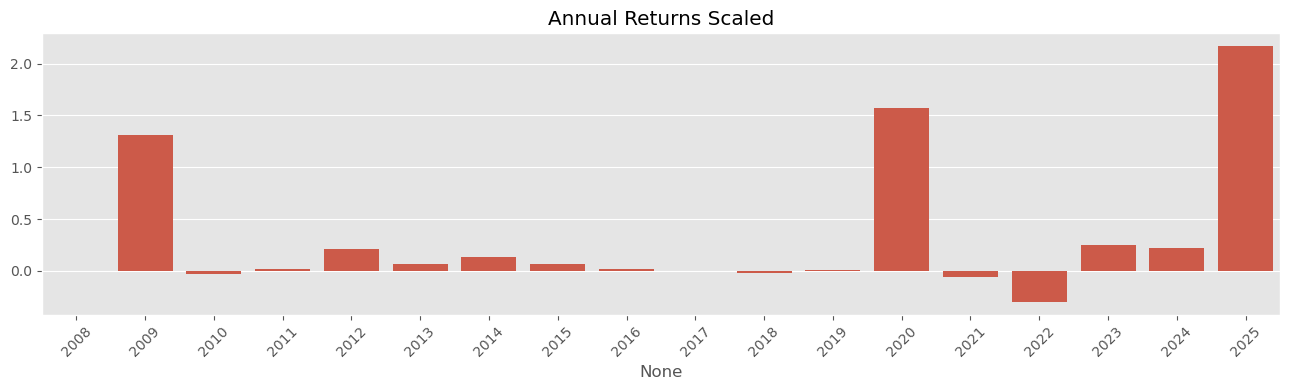

In [510]:
df_vol = df_price.pct_change().rolling(window=vol_window).std() * np.sqrt(252)
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[df_vol.equity > vol_threshold_buy, 'equity'] = 1
df_signal.loc[df_vol.equity < vol_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Volatility-driven equity-to-bond switching')

## 4. Drawdown-driven equity-to-bond switching

win/loss ratio: 1.19
sharpe ratio: 0.42
annualized return: 4.56%
multiplier: 7.03
annualized return scaled: 26.40%


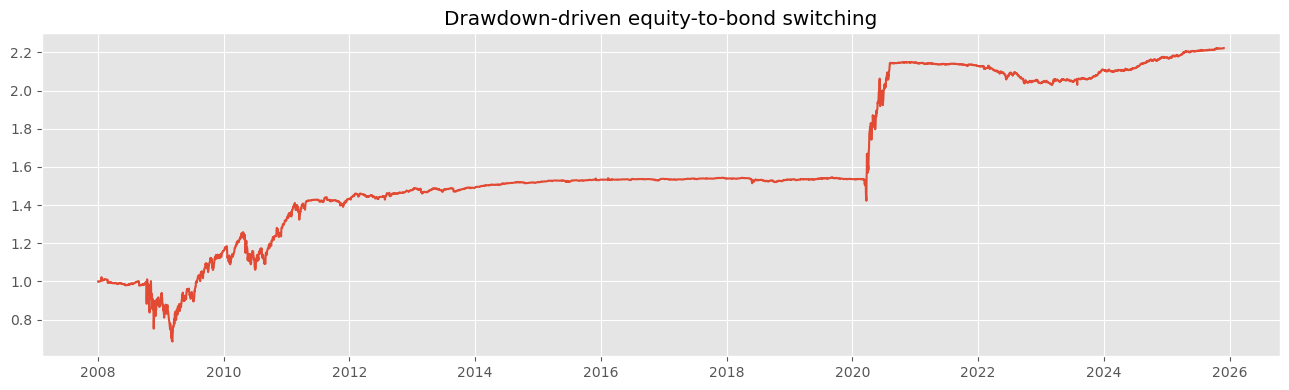

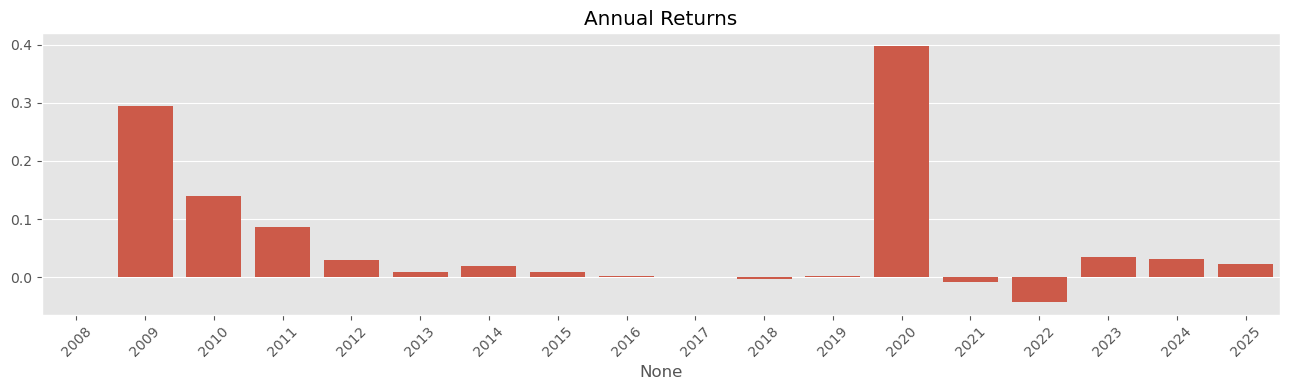

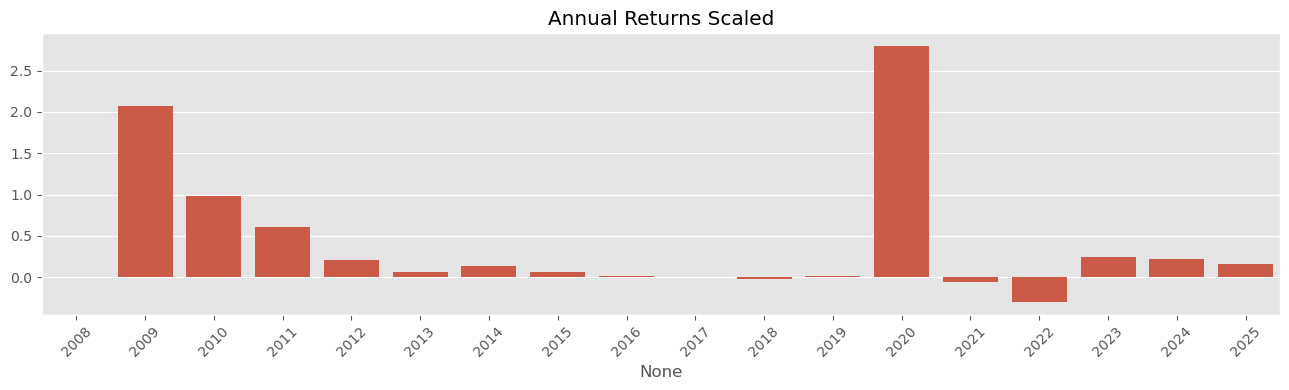

In [511]:
dd = df_price.equity / df_price.equity.expanding().max()
df_signal = pd.DataFrame(index=df_price.index, columns=df_price.columns, dtype=float)
df_signal.loc[dd < dd_threshold_buy, 'equity'] = 1
df_signal.loc[dd >= dd_threshold_sell, 'equity'] = 0
df_signal = df_signal.ffill()
df_signal.loc[:, 'equity'] = df_signal.equity.fillna(0)
df_signal.loc[df_signal.equity == 0, 'bond'] = 1
df_signal.loc[df_signal.equity == 1, 'bond'] = 0
portfolio_level = df_price.pct_change().multiply(df_signal).sum(axis=1).add(1).cumprod()
compute_metrics(portfolio_level, 'Drawdown-driven equity-to-bond switching')